# Clima de las estaciones del SMN por provincia (2018–2025)

Para saber si el clima tuvo algo que ver con un brote de dengue hay que conocer el clima de cada provincia en cada semana, no un promedio fijo por mes. Un mes de enero lluvioso y uno seco no pueden compartir el mismo valor, y justamente esa diferencia es la que interesa. Este notebook parte de los registros **diarios** del Servicio Meteorológico Nacional y los convierte en tablas de temperatura, humedad y lluvia por provincia, semanales y mensuales, para 2018–2025.

El camino es este: leemos y limpiamos los registros de las estaciones, comprobamos cuánta información tiene cada una, asignamos cada estación a su provincia y resumimos por semana y por mes. Cerramos comparando el resultado con valores de referencia para saber si es razonable. Las tablas que salen de acá se usan en el modelo SQL (notebook 03), en el análisis de clima y brotes (04) y en el pronóstico (05).

Las preguntas que ordenan el recorrido:

1. ¿Qué calidad tienen los registros diarios y cuántas estaciones hay por provincia?
2. ¿Cómo se pasa de estaciones a provincias sin inventar datos?
3. ¿El resultado es coherente con las temperaturas medias de referencia?

**Fuente:** Servicio Meteorológico Nacional, [datos meteorológicos diarios](https://www.smn.gob.ar/descarga-de-datos) de las estaciones del país: un archivo con 1991–2020, otro desde 2021 y la tabla de estaciones con su provincia. Se usan solo temperatura media, precipitación y humedad relativa.

## 1. Carga y limpieza

### 1.1 Librerías y rutas

In [1]:
from pathlib import Path
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def encontrar_raiz(archivo=("data", "raw", "Dengue y Zika - Dic. 2019.xlsx")):
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for candidata in (base, base / "vigilancia-dengue-argentina"):
            if candidata.joinpath(*archivo).exists():
                return candidata
    raise FileNotFoundError("No se encontró data/raw/" + archivo[-1] + " desde " + str(cwd))

ROOT = encontrar_raiz()
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
IMAGES = ROOT / "images"
for carpeta in (INTERIM, PROCESSED, IMAGES):
    carpeta.mkdir(parents=True, exist_ok=True)

# Paleta del dashboard de Power BI (tema "Dengue Portfolio")
AZUL_OSCURO, ROJO, AZUL, NARANJA, VERDE, VIOLETA, AMARILLO, GRIS = (
    "#2C3E50", "#B71C1C", "#1F6FB2", "#E08E45", "#6B8E23", "#8E44AD", "#F1C40F", "#7F8C8D")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9CA3AF", "axes.labelcolor": "#1F2937", "text.color": "#1F2937",
    "xtick.color": "#374151", "ytick.color": "#374151",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.prop_cycle": plt.cycler(color=[AZUL_OSCURO, ROJO, AZUL, NARANJA, VERDE, VIOLETA, AMARILLO, GRIS]),
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "legend.frameon": False,
})

### 1.2 Parámetros

El período de estudio es el de los casos de dengue, de 2018 a 2025. Para leer el archivo histórico, que pesa unos 70 MB, se usa `python-calamine` si está instalado: baja la lectura de varios minutos a segundos. Si no lo está, el notebook funciona igual con `openpyxl`, más lento.

In [2]:
INICIO, FIN = pd.Timestamp("2018-01-01"), pd.Timestamp("2025-12-31")   # período de los casos de dengue
VARIABLES = ["TMEDIA", "PRECIP", "HUM_REL"]
COLUMNAS = ["NRO_OMM", "NOMBRE", "FECHA"] + VARIABLES

def clave(texto):
    """Minúsculas y sin tildes, para comparar nombres."""
    texto = unicodedata.normalize("NFD", str(texto).strip().lower())
    return "".join(c for c in texto if unicodedata.category(c) != "Mn")

# El archivo .xlsx pesa unos 70 MB: con python-calamine se lee en segundos; sin él, openpyxl tarda varios minutos
try:
    import python_calamine  # noqa: F401
    MOTOR = "calamine"
except ImportError:
    MOTOR = None
print("Motor de lectura de Excel:", MOTOR or "openpyxl (más lento)")

Motor de lectura de Excel: openpyxl (más lento)


### 1.3 Lectura

In [3]:
CLIMA = RAW / "clima"
usar = lambda columna: columna.strip() in COLUMNAS     # los encabezados del .lst vienen con espacios

historico = pd.read_excel(CLIMA / "datos_meteorologicos_1991_2020.xlsx", sheet_name="Datos meteorológicos",
                          usecols=usar, engine=MOTOR)
reciente = pd.read_csv(CLIMA / "datos_meteorologicos_desde_2021.lst", sep="\t", usecols=usar, dtype=str)

print(f"1991-2020 (.xlsx): {historico.shape[0]:,} filas | desde 2021 (.lst): {reciente.shape[0]:,} filas")

1991-2020 (.xlsx): 992,184 filas | desde 2021 (.lst): 179,730 filas


### 1.4 Limpieza

Las dos fuentes comparten estructura, pero el SMN tiene convenciones propias que hay que respetar:

- Algunos archivos traen el **encabezado repetido como si fuera un registro**. Esas filas se descartan.
- `S/D` o una celda vacía significan sin dato, **salvo en la precipitación**: según el diccionario del SMN, una celda vacía en `PRECIP` quiere decir **sin lluvia (0 mm)**, y solo `S/D` es un dato faltante real.
- Una estación (`PRESIDENCIA ROQUE SAENZ PEÑA`) aparece con dos nombres, con y sin el sufijo `AERO`.

In [4]:
def limpiar(df):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Filas corruptas: el encabezado quedó repetido como si fuera un registro
    es_dato = pd.to_numeric(df["NRO_OMM"], errors="coerce").notna()
    df = df[es_dato].copy()
    df["NRO_OMM"] = df["NRO_OMM"].astype(float).astype(int)
    df["NOMBRE"] = df["NOMBRE"].astype(str).str.strip()

    if not pd.api.types.is_datetime64_any_dtype(df["FECHA"]):
        df["FECHA"] = pd.to_datetime(df["FECHA"].astype(str).str.strip(), format="mixed", dayfirst=True, errors="coerce")

    # Temperatura y humedad: 'S/D' o vacío significa sin dato
    for col in ["TMEDIA", "HUM_REL"]:
        texto = df[col].astype("string").str.strip()
        df[col] = pd.to_numeric(texto.mask(texto.isin(["S/D", ""])), errors="coerce")

    # Precipitación: según el diccionario del SMN, celda vacía = sin lluvia (0 mm) y 'S/D' = sin dato
    texto = df["PRECIP"].astype("string").str.strip()
    sin_dato = (texto == "S/D").fillna(False).to_numpy(dtype=bool)
    vacio = (texto.isna() | (texto == "")).fillna(False).to_numpy(dtype=bool)
    df["PRECIP"] = pd.to_numeric(texto.mask(vacio, "0").mask(sin_dato), errors="coerce")
    return df

historico, reciente = limpiar(historico), limpiar(reciente)
clima = pd.concat([historico, reciente], ignore_index=True)
del historico, reciente

clima = clima[clima["FECHA"].between(INICIO, FIN)].copy()
clima["NOMBRE"] = clima["NOMBRE"].replace({"PRESIDENCIA ROQUE SAENZ PEÑA": "PRESIDENCIA ROQUE SAENZ PEÑA AERO"})
print(f"Registros diarios entre {INICIO:%Y-%m-%d} y {FIN:%Y-%m-%d}: {len(clima):,}")
print(f"Fechas que no se pudieron interpretar: {int(clima['FECHA'].isna().sum())}")

Registros diarios entre 2018-01-01 y 2025-12-31: 263,196
Fechas que no se pudieron interpretar: 0


## 2. Auditoría

### 2.1 Duplicados y estaciones

In [5]:
dup = clima.duplicated(subset=["NRO_OMM", "FECHA"]).sum()
print("Duplicados por estación y día:", dup)
nombres = clima.groupby("NRO_OMM")["NOMBRE"].nunique()
print("Estaciones con más de un nombre:", int((nombres > 1).sum()))
print("Estaciones:", clima["NRO_OMM"].nunique())

Duplicados por estación y día: 0
Estaciones con más de un nombre: 0
Estaciones: 91


No hay días duplicados por estación y hay 91 estaciones con registros en el período.

### 2.2 Valores nulos

In [6]:
pd.DataFrame({
    "nulos": clima[VARIABLES].isna().sum(),
    "% nulos": (clima[VARIABLES].isna().mean() * 100).round(2),
})

,nulos,% nulos
TMEDIA,2082,0.79
PRECIP,526,0.20
HUM_REL,2205,0.84


Faltan el 0,8 % de las temperaturas, el 0,8 % de la humedad y solo el 0,2 % de la precipitación. Este último porcentaje es tan bajo justamente por la convención del SMN: los días sin lluvia son ceros y no faltantes.

### 2.3 Rangos físicos

In [7]:
print("TMEDIA fuera de [-30, 45] °C:", int(((clima["TMEDIA"] < -30) | (clima["TMEDIA"] > 45)).sum()))
print("HUM_REL fuera de [0, 100] %:", int(((clima["HUM_REL"] < 0) | (clima["HUM_REL"] > 100)).sum()))
print("PRECIP negativa:", int((clima["PRECIP"] < 0).sum()))
print("PRECIP máxima diaria (mm):", clima["PRECIP"].max())
clima[VARIABLES].describe().round(1)

TMEDIA fuera de [-30, 45] °C: 0
HUM_REL fuera de [0, 100] %: 0
PRECIP negativa: 0
PRECIP máxima diaria (mm): 276.0


,TMEDIA,PRECIP,HUM_REL
count,261114.0,262670.0,260991.0
mean,16.9,2.0,64.5
std,7.4,8.2,17.0
min,-14.7,0.0,1.0
25%,11.3,0.0,52.0
50%,17.1,0.0,66.0
75%,22.7,0.0,77.0
max,39.4,276.0,100.0


Ningún valor viola una regla física básica: no hay temperaturas imposibles, humedades fuera de 0–100 % ni lluvias negativas. La precipitación diaria máxima (276 mm) es un valor extremo pero posible.

## 3. De estaciones a provincias

### 3.1 Qué estación pertenece a qué provincia

La tabla de estaciones del SMN trae la provincia de cada una. Se unen la del archivo histórico y la del archivo reciente y se verifica que ninguna estación figure en dos provincias distintas. CABA se suma a Buenos Aires, igual que en los casos (notebook 01).

In [8]:
est_hist = pd.read_excel(CLIMA / "datos_meteorologicos_1991_2020.xlsx", sheet_name="Estaciones meteorológicas", engine=MOTOR)
est_rec = pd.read_excel(CLIMA / "estaciones_meteorologicas_2021-2026.xlsx")
estaciones = pd.concat([est_hist, est_rec]).drop_duplicates(subset=["NRO_OMM", "PROVINCIA"])

# Una estación no puede figurar en dos provincias distintas según cada archivo
assert estaciones["NRO_OMM"].is_unique, "Hay estaciones asignadas a provincias distintas"

poblacion = pd.read_csv(RAW / "poblacion_provincias_censo2022.csv")
por_clave = {clave(p): p for p in poblacion["provincia"]}
por_clave["ciudad autonoma de buenos aires"] = "Buenos Aires"       # los casos de CABA se suman a Buenos Aires
estaciones["provincia"] = estaciones["PROVINCIA"].map(clave).map(por_clave)
assert estaciones["provincia"].notna().all(), "Provincia de estación sin equivalente"

clima = clima.merge(estaciones[["NRO_OMM", "provincia"]], on="NRO_OMM", how="left")
print("Registros sin provincia:", int(clima["provincia"].isna().sum()))
print("Provincias sin ninguna estación:", sorted(set(poblacion["provincia"]) - set(clima["provincia"])))
estaciones_prov = clima.groupby("provincia")["NRO_OMM"].nunique().rename("estaciones")
estaciones_prov.to_frame().T

Registros sin provincia: 0
Provincias sin ninguna estación: []


provincia,Buenos Aires,Catamarca,Chaco,Chubut,Corrientes,Córdoba,Entre Ríos,Formosa,Jujuy,La Pampa,...,Neuquén,Río Negro,Salta,San Juan,San Luis,Santa Cruz,Santa Fe,Santiago del Estero,Tierra del Fuego,Tucumán
estaciones,22,2,2,3,3,8,3,2,3,2,...,1,5,3,2,2,6,6,1,2,1


Las 23 provincias tienen al menos una estación, pero la cantidad varía mucho: Buenos Aires tiene 23 (incluye las dos de CABA) y Neuquén, Santiago del Estero, Tucumán tienen una sola. Una provincia con una única estación queda representada por ese punto, así que se la lee como una aproximación.

### 3.2 Estaciones de las provincias con más casos

In [9]:
# Estaciones que representan a cada provincia (las seis provincias con más casos y Jujuy, por su gradiente de altura)
principales = ["Buenos Aires", "Córdoba", "Santa Fe", "Tucumán", "Salta", "Chaco", "Misiones", "Jujuy"]
detalle = (estaciones[estaciones["provincia"].isin(principales)]
           .sort_values(["provincia", "NOMBRE"])[["provincia", "NOMBRE", "ALTURA"]]
           .rename(columns={"NOMBRE": "estación", "ALTURA": "altura (m)"}))
display(detalle[detalle["provincia"] != "Buenos Aires"].set_index(["provincia", "estación"]))
print("Buenos Aires:", int((estaciones["provincia"] == "Buenos Aires").sum()), "estaciones (incluye las dos de CABA)")

altura (m)
provincia estación                                     
Chaco     PRESIDENCIA ROQUE SAENZ PEÑA AERO          93
          RESISTENCIA AERO                           52
Córdoba   CORDOBA AERO                              495
          CORDOBA OBSERVATORIO                      425
          LABOULAYE AERO                            137
          MARCOS JUÁREZ AERO                        114
          PILAR OBSERVATORIO                        338
          RÍO CUARTO AERO                           421
          VILLA DE MARÍA DEL RÍO SECO               341
          VILLA DOLORES AERO                        569
Jujuy     JUJUY AERO                                909
          JUJUY U N                                1302
          LA QUIACA OBSERVATORIO                   3459
Misiones  BERNARDO DE IRIGOYEN AERO                 815
          IGUAZÚ AERO                               270
          OBERÁ                                     303
          POSADAS AERO                              125
Salta     ORÁN AERO                                 357
          SALTA AERO                               1221
          TARTAGAL AERO                             450
Santa Fe  CERES AERO                                 88
          EL TRÉBOL                                  96
          RECONQUISTA AERO                           53
          ROSARIO AERO                               25
          SAUCE VIEJO AERO                           18
          VENADO TUERTO                             112
Tucumán   TUCUMÁN AERO                              450

Buenos Aires: 23 estaciones (incluye las dos de CABA)


En Jujuy conviven estaciones de la Quebrada y la Puna: La Quiaca está a 3.459 metros. Como el promedio provincial las pone en pie de igualdad, la temperatura de Jujuy queda por debajo de la que se vive en las zonas bajas donde se notifican la mayoría de los casos. Es una limitación que conviene tener presente.

### 3.3 Cobertura de cada estación

In [10]:
dias_esperados = (FIN - INICIO).days + 1
cob = (clima.groupby(["NRO_OMM", "NOMBRE", "provincia"])
       .agg(dias=("FECHA", "nunique"), tmedia=("TMEDIA", "count"), hum=("HUM_REL", "count"))
       .reset_index())
cob["% días con registro"] = (cob["dias"] / dias_esperados * 100).round(1)
cob["% con humedad"] = (cob["hum"] / dias_esperados * 100).round(1)
print(f"Días del período: {dias_esperados:,}")
print("Estaciones con menos del 90 % de los días registrados:")
display(cob[cob["% días con registro"] < 90][["NOMBRE", "provincia", "% días con registro", "% con humedad"]]
        .sort_values("% días con registro"))
print("Estaciones con menos del 50 % de humedad:", int((cob["% con humedad"] < 50).sum()))

Días del período: 2,922
Estaciones con menos del 90 % de los días registrados:


,NOMBRE,provincia,% días con registro,% con humedad
44,EL TREBOL,Santa Fe,63.9,50.3
70,CORONEL PRINGLES AERO,Buenos Aires,67.7,67.7


Estaciones con menos del 50 % de humedad: 0


Casi todas las estaciones tienen registros casi todos los días. Las excepciones son El Trebol (Santa Fe, 63,9 %); Coronel Pringles Aero (Buenos Aires, 67,7 %). Los períodos sin registro no se rellenan: se manejan con la regla de cobertura mínima de la sección siguiente.

## 4. Agregación semanal y mensual

La regla busca no inventar datos y no dar peso a períodos casi vacíos:

1. Cada estación aporta un valor por período solo si tiene suficientes días con dato: **5 de 7 días** en una semana y el **80 % de los días** en un mes.
2. La precipitación acumulada y los días con lluvia (más de 1 mm) se calculan sobre los días con dato y se llevan a la longitud completa del período.
3. El valor de la provincia es el **promedio simple** de sus estaciones con dato válido. Se guarda además cuántas estaciones aportaron (`n_estaciones`).

Las semanas siguen el calendario ISO (lunes a domingo), la misma convención que usamos para fechar los casos.

In [11]:
# Cada estación aporta un valor por período (semana o mes) solo si tiene suficientes días con dato;
# la precipitación acumulada y los días de lluvia se llevan a la longitud completa del período.
# La provincia es el promedio simple de sus estaciones con dato válido.

clima["lluvia"] = (clima["PRECIP"] > 1).astype(float).where(clima["PRECIP"].notna())   # día con más de 1 mm

def agregar(df, periodo, dias_periodo, min_dias):
    g = df.groupby(["provincia", "NRO_OMM"] + periodo)
    est = g.agg(
        dias_t=("TMEDIA", "count"), temp_media=("TMEDIA", "mean"),
        dias_p=("PRECIP", "count"), precip=("PRECIP", "mean"), lluvia=("lluvia", "mean"),
        dias_h=("HUM_REL", "count"), hum_rel=("HUM_REL", "mean"),
    ).reset_index()
    est["largo"] = dias_periodo(est)
    est["min"] = min_dias(est["largo"])
    est["temp_media"] = est["temp_media"].where(est["dias_t"] >= est["min"])
    est["hum_rel"] = est["hum_rel"].where(est["dias_h"] >= est["min"])
    valido_p = est["dias_p"] >= est["min"]
    est["precip_mm"] = (est["precip"] * est["largo"]).where(valido_p)
    est["dias_lluvia"] = (est["lluvia"] * est["largo"]).where(valido_p)

    prov = (est.groupby(["provincia"] + periodo)
            .agg(temp_media=("temp_media", "mean"), precip_mm=("precip_mm", "mean"),
                 hum_rel=("hum_rel", "mean"), dias_lluvia=("dias_lluvia", "mean"),
                 n_estaciones=("temp_media", "count"))
            .reset_index())
    return prov

### 4.1 Tabla semanal

In [12]:
iso = clima["FECHA"].dt.isocalendar()
clima["año"] = iso["year"].astype(int)          # año y semana ISO: la misma convención que SE_inicio / SE_fin de los casos
clima["SE"] = iso["week"].astype(int)

semanal = agregar(clima, ["año", "SE"], lambda e: pd.Series(7, index=e.index), lambda n: n.map(lambda _: 5))
# El 29-31/12/2025 pertenece a la semana ISO 1 de 2026, que queda incompleta: se descarta
semanal = semanal[semanal["año"] <= 2025].sort_values(["provincia", "año", "SE"]).reset_index(drop=True)
print(f"Tabla semanal: {semanal.shape[0]:,} filas")
semanal.head()

Tabla semanal: 9,591 filas


,provincia,año,SE,temp_media,precip_mm,hum_rel,dias_lluvia,n_estaciones
0,Buenos Aires,2018,1,23.637662,15.031818,48.207792,1.000000,22
1,Buenos Aires,2018,2,25.556494,32.954545,59.883117,1.500000,22
2,Buenos Aires,2018,3,24.375325,4.654545,61.88961,0.636364,22
3,Buenos Aires,2018,4,22.872078,10.763636,61.655844,0.772727,22
4,Buenos Aires,2018,5,25.115584,5.559091,59.019481,0.409091,22


### 4.2 Tabla mensual

In [13]:
clima["año_cal"] = clima["FECHA"].dt.year
clima["mes"] = clima["FECHA"].dt.month
clima["dias_mes"] = clima["FECHA"].dt.days_in_month

mensual = agregar(
    clima.rename(columns={"año": "año_iso"}).rename(columns={"año_cal": "año"}),
    ["año", "mes"],
    lambda e: e.merge(clima[["año_cal", "mes", "dias_mes"]].drop_duplicates()
                      .rename(columns={"año_cal": "año"}), on=["año", "mes"], how="left")["dias_mes"].values,
    lambda n: (n * 0.8).round(),
)
mensual = mensual.sort_values(["provincia", "año", "mes"]).reset_index(drop=True)
print(f"Tabla mensual: {mensual.shape[0]:,} filas")
mensual.head()

Tabla mensual: 2,208 filas


,provincia,año,mes,temp_media,precip_mm,hum_rel,dias_lluvia,n_estaciones
0,Buenos Aires,2018,1,24.169648,67.054545,57.818182,4.136364,22
1,Buenos Aires,2018,2,23.531169,43.909091,60.444805,2.818182,22
2,Buenos Aires,2018,3,19.879326,68.836364,62.394428,4.681818,22
3,Buenos Aires,2018,4,18.815758,143.422727,78.381818,7.681818,22
4,Buenos Aires,2018,5,13.615249,118.945455,82.293255,7.727273,22


### 4.3 Valores faltantes

In [14]:
esperado_mensual = 23 * 12 * 8
print(f"Filas mensuales: {len(mensual)} de {esperado_mensual} esperadas (23 provincias x 96 meses)")
for nombre, tabla in (("mensual", mensual), ("semanal", semanal)):
    print(f"\nValores faltantes en la tabla {nombre}:")
    print(tabla[["temp_media", "precip_mm", "hum_rel", "dias_lluvia"]].isna().sum().to_string())
print("\nProvincia-mes sin humedad:")
sin_hum = mensual[mensual["hum_rel"].isna()].groupby("provincia").size()
print(sin_hum.to_string() if len(sin_hum) else "ninguno")

Filas mensuales: 2208 de 2208 esperadas (23 provincias x 96 meses)

Valores faltantes en la tabla mensual:
temp_media     0
precip_mm      0
hum_rel        0
dias_lluvia    0

Valores faltantes en la tabla semanal:
temp_media     0
precip_mm      0
hum_rel        0
dias_lluvia    0

Provincia-mes sin humedad:
ninguno


Las tablas quedan completas: 2.208 filas mensuales (23 provincias por 96 meses) y 9.591 semanales, sin ningún valor faltante. Con 91 estaciones y la regla de cobertura mínima, todas las provincias tienen dato en todos los períodos.

## 5. ¿Es razonable el resultado?

### 5.1 Contra las temperaturas medias de referencia

El proyecto incluye un archivo con las temperaturas medias mensuales de cada provincia (`Temp medias mensuales por provincia.xlsx`). Son valores históricos y no de 2018–2025, así que no esperamos que coincidan, pero sí que estén cerca.

In [15]:
# Control: ¿la temperatura recalculada es coherente con las temperaturas medias mensuales que usaba la versión anterior?
normales = pd.read_excel(RAW / "Temp medias mensuales por provincia.xlsx")
normales = normales.melt(id_vars="provincia", var_name="mes", value_name="temp_normal")
normales["mes"] = normales["mes"].astype(int)

recalculada = mensual.groupby(["provincia", "mes"])["temp_media"].mean().rename("temp_2018_2025").reset_index()
comp = normales.merge(recalculada, on=["provincia", "mes"])
comp["diferencia"] = comp["temp_2018_2025"] - comp["temp_normal"]

resumen_dif = comp.groupby("provincia")["diferencia"].agg(["mean", lambda s: s.abs().max()])
resumen_dif.columns = ["diferencia media (°C)", "diferencia máxima absoluta (°C)"]
print(f"Provincias comparadas: {comp['provincia'].nunique()} | meses: {len(comp)}")
print(f"Diferencia media: {comp['diferencia'].mean():+.2f} °C | máxima absoluta: {comp['diferencia'].abs().max():.2f} °C")
resumen_dif.round(2).sort_values("diferencia máxima absoluta (°C)", ascending=False).head(6)

Provincias comparadas: 23 | meses: 276
Diferencia media: +0.57 °C | máxima absoluta: 2.27 °C


,diferencia media (°C),diferencia máxima absoluta (°C)
provincia,,
Jujuy,-1.58,2.27
La Rioja,1.26,2.21
San Juan,1.11,2.09
Formosa,1.19,1.94
Santa Fe,0.94,1.57
Misiones,0.83,1.55


La temperatura recalculada para 2018–2025 es en promedio 0,57 °C más cálida que la de referencia, y la mayor diferencia mensual en valor absoluto es de 2,27 °C. La diferencia es positiva en casi todas las provincias, coherente con un período reciente más cálido que el de referencia. El caso más llamativo es Jujuy (la mayor diferencia, −1,58 °C en promedio), y se explica por lo que vimos en la sección 3.2: nuestro promedio incluye a La Quiaca. En las demás provincias la diferencia máxima es de 2,21 °C.

### 5.2 Un año no es igual a otro

La tabla fija de medias mensuales trata a todos los eneros por igual. Los registros diarios muestran cuánto se aparta cada año del promedio, y ese apartamiento es la información que necesitamos para relacionar clima y brotes.

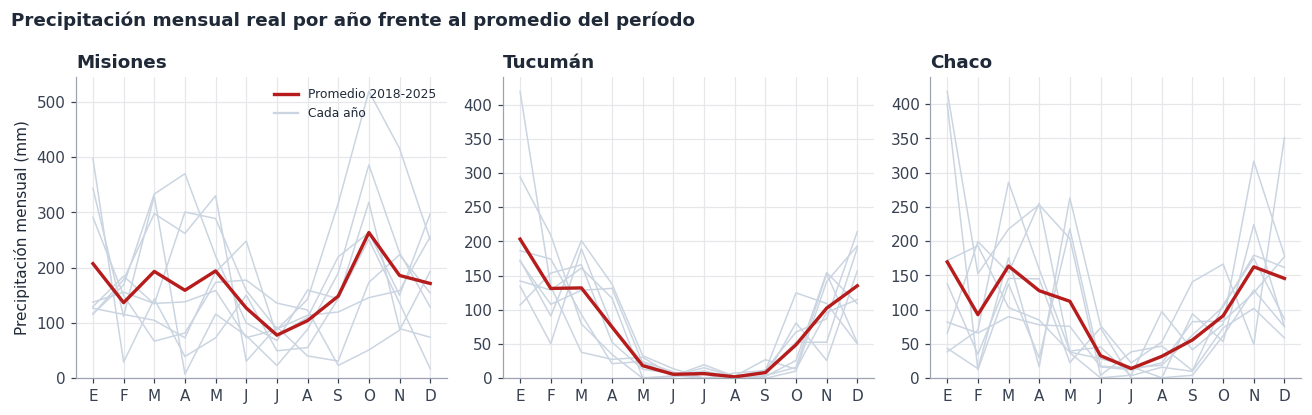

In [16]:
# Lo que una tabla fija de "normales" no puede mostrar: la variación real de un año a otro
provs = ["Misiones", "Tucumán", "Chaco"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=False)
for ax, prov in zip(axes, provs):
    d = mensual[mensual["provincia"] == prov]
    for año, g in d.groupby("año"):
        ax.plot(g["mes"], g["precip_mm"], color="#CBD5E1", lw=1)
    media = d.groupby("mes")["precip_mm"].mean()
    ax.plot(media.index, media.values, color=ROJO, lw=2.2, label="Promedio 2018-2025")
    ax.plot([], [], color="#CBD5E1", label="Cada año")
    ax.set_title(prov)
    ax.set_ylim(bottom=0)
    ax.set_xticks(range(1, 13), list("EFMAMJJASOND"))
axes[0].set_ylabel("Precipitación mensual (mm)")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Precipitación mensual real por año frente al promedio del período", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

En Misiones, Tucumán y Chaco, la lluvia de un mismo mes varía muchas veces entre años: en enero, por ejemplo, hay años con menos de 100 mm y años con más de 400. Un promedio fijo borra todo eso.

## 6. Guardado

In [17]:
mensual.to_csv(PROCESSED / "clima_provincia_mensual.csv", index=False, encoding="utf-8")
semanal.to_csv(PROCESSED / "clima_provincia_semanal.csv", index=False, encoding="utf-8")
print("Guardados en data/processed/:")
print(f" - clima_provincia_mensual.csv: {mensual.shape[0]:,} filas")
print(f" - clima_provincia_semanal.csv: {semanal.shape[0]:,} filas")

Guardados en data/processed/:
 - clima_provincia_mensual.csv: 2,208 filas
 - clima_provincia_semanal.csv: 9,591 filas


## 7. Resumen y límites

Quedan dos tablas por provincia, con temperatura media, precipitación acumulada, humedad relativa y días con lluvia: una **semanal** (9.591 filas) y una **mensual** (2.208 filas), completas para 2018–2025 y con control contra valores de referencia.

Lo que hay que tener presente al usarlas:

- La provincia es el promedio simple de sus estaciones. En provincias grandes o con relieve marcado (Jujuy, Salta, Buenos Aires) el valor es una síntesis gruesa y no refleja el clima de cada departamento.
- Neuquén, Santiago del Estero, Tucumán dependen de una sola estación.
- La temperatura de Jujuy está sesgada hacia abajo por La Quiaca.
- Las tablas no incluyen días sin dato: cuando una estación no alcanza la cobertura mínima, simplemente no aporta ese período.